# Probability & Statistics Lab 1: Naive Bayes Classifier

Work breakdown:
-   *Mariia-Daryna Zahariuk* : Data preprocessing, Loading the stop words, Data visualization, Final conclusions;
-   *Tymur* : Classifier implementation, Derivation of log-evidence calculation, Prediction implementation;
-   *Kateryna* : Classifier evaluation, Additional task.

## Introduction

During the first three weeks, you learned a couple of essential notions
and theorems, and one of the most important among them is the **Bayes
theorem**:

$$
\mathsf P(A \mid B) = \frac{\mathsf P(A)\mathsf P(B \mid A)}{\mathsf P(B)}.
$$


**Naive Bayes Classifier** is a simple algorithm, which is based on
Bayes theorem and used for solving classification problems.

**Classification problem** is a problem in which an observation has to
be classified in one of the $n$ classes based on its similarity with
observations in each class.

It is a **probabilistic classifier**, which means it predicts based on
the probability of an observation belonging to each class. To compute
it, this algorithm uses **Bayes' formula** as:
$$
\mathsf P (\text{class}_i \mid \text{observation}) = \frac{\mathsf P(\text{class}_i) \mathsf P(\text{observation} \mid \text{class}_i)}{\mathsf P(\text{observation})}. \quad \quad (1)
$$
Breaking down the pieces of the formula,
- $\mathsf P(\text{class}_i)$ is referred to as a **prior** [distribution]: it provides initial class probabilities, influenced by prior beliefs about the problem.
- $\mathsf P(\text{observation} \mid \text{class}_i)$ is the **likelihood**: it tells how likely observations are for a chosen class.
- $\mathsf P(\text{observation})$ is the **evidence**; usually isn't computed directly and used as a normalization constant s.t. sum of $\mathsf P (\text{class}_i \mid \text{observation})$ for all classes is $1$.


This lab focuses on binary classification of text. Text can be considered a sequence of observations/features, with many ways to split it into individual/elementary features. Here, we split the text by words, and one word is considered a feature $\text{feature}_j$:
$\mathsf P(\text{text}) = \mathsf P(\text{features}_1, \text{feature}_2, \dots, \text{feature}_N) = \mathsf P(\text{features}_1)\cdot \mathsf P(\text{feature}_2 \mid \text{feature}_1) \cdot \mathsf P(\text{feature}_3 \mid (\text{feature}_1, \text{feature}_2)) \dots.$

However, modeling such long conditionals is complex, compute-intensive, and requires lots of data.

One way to deal with this is to assume independence, where one can write: $\mathsf P(\text{text}) = \prod_{j=1}^N \mathsf P(\text{feature}_j).$
Or, one could assume the dependence only on the previous word, which will be explored in the additional task!

$\mathsf P(\text{feature}_j)$ is unknown, and we estimate it empirically using the training data split. The empirical probability of some feature $x$ would be $\frac{\text{\# of } x}{\text{total \# of features}}.$
Note that such an approach would turn $\mathsf P(\text{text})$ to $0$ for any completely new feature (as its count among data is zero), which is undesirable.
A common way to deal with this is [Laplace smoothing](https://en.wikipedia.org/wiki/Additive_smoothing). No need to dive deeply into this now, as you will develop a better intuition as you progress through the course.
In this lab, you shall apply Laplace smoothing to both class priors and feature ($\log$–)probabilities.

#### Implementation note

Instead of storing and calculating probabilities directly, many ML solutions prefer computations in $\log$ domain. One of the reasons is numerical stability, which shows up in $\prod_{j=1}^N \mathsf P(\text{feature}_j)$:
each $\mathsf P(\text{feature}_j) \in (0, 1)$ in practice, resulting in tiny final product, which floating-point numbers the computer uses can't store as accurately.
However, in the logarithmic domain even $10^{-100}$ corresponds to an order of magnitude of $-100$.

So, let's rewrite the equation we estimate:
$$
\log [\mathsf P (\text{class}_i \mid \text{observation})] = \underbrace{\log[\mathsf P(\text{class}_i)] + \sum_{j=1}^N \log[\mathsf P(\text{feature}_j)]}_{\text{used to be a numerator, } L_i} - \overbrace{\log[\mathsf P(\text{observation})]}^{\text{used to be a denominator, log-evidence}}. \quad \quad (2)
$$


[A video example of a Naive Bayes](https://www.youtube.com/watch?v=O2L2Uv9pdDA).


### Outline of the work

1.  **Data preprocessing** (1 point) 
2.  **Data visualization** (1 point) 
3.  **Classifier implementation from scratch** (1.5 points)
4.  **Measurements of effectiveness of your classifier** (1.5 points)
5.  **Additional task** (up to 2 points, optional)


*Please submit a pre-executed `.ipynb` notebook for easier evaluation.*


### Data preprocessing

In [33]:
from collections import defaultdict
import math
import pathlib
import re
import pandas as pd
import numpy as np


class Dataset:
    def __init__(self, dataset_dir_path: pathlib.Path):
        self.train_df = pd.read_csv(dataset_dir_path / "train.csv")
        self.test_df = pd.read_csv(dataset_dir_path / "test.csv")

        self.bag_of_words_per_label_id: dict[int, dict[str, int]] = {}
        self.bag_of_log_probabilities_per_label_id: dict[int, dict[str, float]] = {}

    def preprocess_text(self, stop_words: list[str]) -> None:
        """
        Adds "label-id" (starting with 0) and "useful-words" columns to dataframes.
        Useful words are the ones that aren't in the stop words list.
        Remove the punctuation, map all the text to one register (e.g., lowercase).

        You may add custom preprocessing if it's justified!
        """
        stop_set = set(stop_words) if stop_words else set()

        def clean_text(text):
            if not isinstance(text, str):
                return []
            # lowercase the text
            text = text.lower()
            # Remove punctuation and split into words
            words = re.findall(r'\b\w+\b', text)
            # Filter out stop words
            return [w for w in words if w not in stop_set]

        # Automatically determine column names for text and labels
        text_col = 'tweet' if 'tweet' in self.train_df.columns else self.train_df.columns[0]
        label_col = 'label' if 'label' in self.train_df.columns else self.train_df.columns[1]

        # 1. Create 'useful-words' column for train and test
        self.train_df['useful-words'] = self.train_df[text_col].apply(clean_text)
        self.test_df['useful-words'] = self.test_df[text_col].apply(clean_text)

        # 2. Create 'label-id' column (starting with 0)
        unique_labels = sorted(self.train_df[label_col].unique())
        label_to_id = {label: i for i, label in enumerate(unique_labels)}

        self.train_df['label-id'] = self.train_df[label_col].map(label_to_id)
        if label_col in self.test_df.columns:
            self.test_df['label-id'] = self.test_df[label_col].map(label_to_id)


    def calculate_classes_prior(self, smoothing_alpha: float) -> np.ndarray:
        """
        :param smoothing_alpha: parameter of Laplace smoothing.
        :return: distribution of classes after smoothing, starting with label-id 0.
        """
        # Number of unique classes (K) and total number of documents (N)
        num_classes = len(self.train_df['label-id'].unique())
        total_documents = len(self.train_df)

        # Calculate the number of documents for each label-id (from 0 to K-1)
        class_counts = self.train_df['label-id'].value_counts().sort_index().values

        # Laplace smoothing formula for prior probabilities:
        # P(C) = (count(C) + alpha) / (N + alpha * num_classes)
        priors = (class_counts + smoothing_alpha) / (total_documents + smoothing_alpha * num_classes)

        return priors

    def compute_bag_of_words(self) -> None:
        """
        Counts the number of occurrences of each word per label id and updates `self.bag_of_words_per_label_id`.

        Bag of words intro: https://machinelearningmastery.com/gentle-introduction-bag-words-model/.
        Advice: you may use `collections.defaultdict` (https://docs.python.org/3/library/collections.html#collections.defaultdict).
        """
        self.bag_of_words_per_label_id = {}

        # every unique label_id in the training dataset
        for label_id in self.train_df['label-id'].unique():
            word_counts = defaultdict(int)
            # Choose all texts with the current label_id and count the occurrences of each word
            subset = self.train_df[self.train_df['label-id'] == label_id]
            for words in subset['useful-words']:
                for word in words:
                    word_counts[word] += 1
            self.bag_of_words_per_label_id[int(label_id)] = dict(word_counts)


    def compute_bag_of_log_probabilities(self, smoothing_alpha: float) -> float:
        """
        Uses `self.bag_of_words_per_label_id` and updates `self.bag_of_log_probabilities_per_label_id`.
        `self.bag_of_log_probabilities_per_label_id` should store log[P(feature_j)].

        :param smoothing_alpha: parameter of Laplace smoothing.
        :return the log-probability of a new(previously unseen) feature, necessary for evaluation on the test set.
        """
        # Total number of unique words in the training dataset (vocabulary size)
        all_words = set()
        for word_counts in self.bag_of_words_per_label_id.values():
            all_words.update(word_counts.keys())
        vocab_size = len(all_words)

        self.bag_of_log_probabilities_per_label_id = {}
        unseen_log_probs = {}

        for label_id, word_counts in self.bag_of_words_per_label_id.items():
            total_words_in_class = sum(word_counts.values())
            # N_c + alpha * |V|
            denominator = total_words_in_class + smoothing_alpha * vocab_size

            log_probs = {}
            for word, count in word_counts.items():
                p = (count + smoothing_alpha) / denominator
                log_probs[word] = math.log(p)

            self.bag_of_log_probabilities_per_label_id[label_id] = log_probs

            # Log-probability for a new (previously unseen) feature
            unseen_p = smoothing_alpha / denominator
            unseen_log_probs[label_id] = math.log(unseen_p)

        return unseen_log_probs

discrimination_dataset_path = pathlib.Path("discrimination")  # change if needed.
discrimination_dataset = Dataset(discrimination_dataset_path)

labels = discrimination_dataset.train_df["label"].unique().tolist()
print(f"Labels are {labels}.")

Labels are ['discrim', 'neutral'].


Loading the stop words

In [34]:
stop_words_path = pathlib.Path("stop_words.txt")  # change if needed.

stop_words: list[str] = []
with open(stop_words_path) as f:
    for line in f:
        stop_words.append(line.strip())

print(f"Some of the stop words are {stop_words[:8]}.")

Some of the stop words are ['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am'].


In [35]:
discrimination_dataset.preprocess_text(stop_words)

In [36]:
classes_alpha = 1.0
classes_prior = discrimination_dataset.calculate_classes_prior(classes_alpha)

In [37]:
discrimination_dataset.compute_bag_of_words()

In [38]:
features_alpha = 1.0
unseen_feature_log_prob = discrimination_dataset.compute_bag_of_log_probabilities(features_alpha)

### Data visualization

Visualize the dataset, its properties, etc. You may use external libraries such as `matplotlib`, `plotly`, etc. Data analysis could provide hints/ideas for downstream classifier evaluation.

/var/folders/lt/68j68y116h146vbgd49gssgm0000gn/T/ipykernel_63989/202912052.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/lt/68j68y116h146vbgd49gssgm0000gn/T/ipykernel_63989/202912052.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/lt/68j68y116h146vbgd49gssgm0000gn/T/ipykernel_63989/202912052.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_words, x="count", y="word", ax=axes[2], palette="mako")


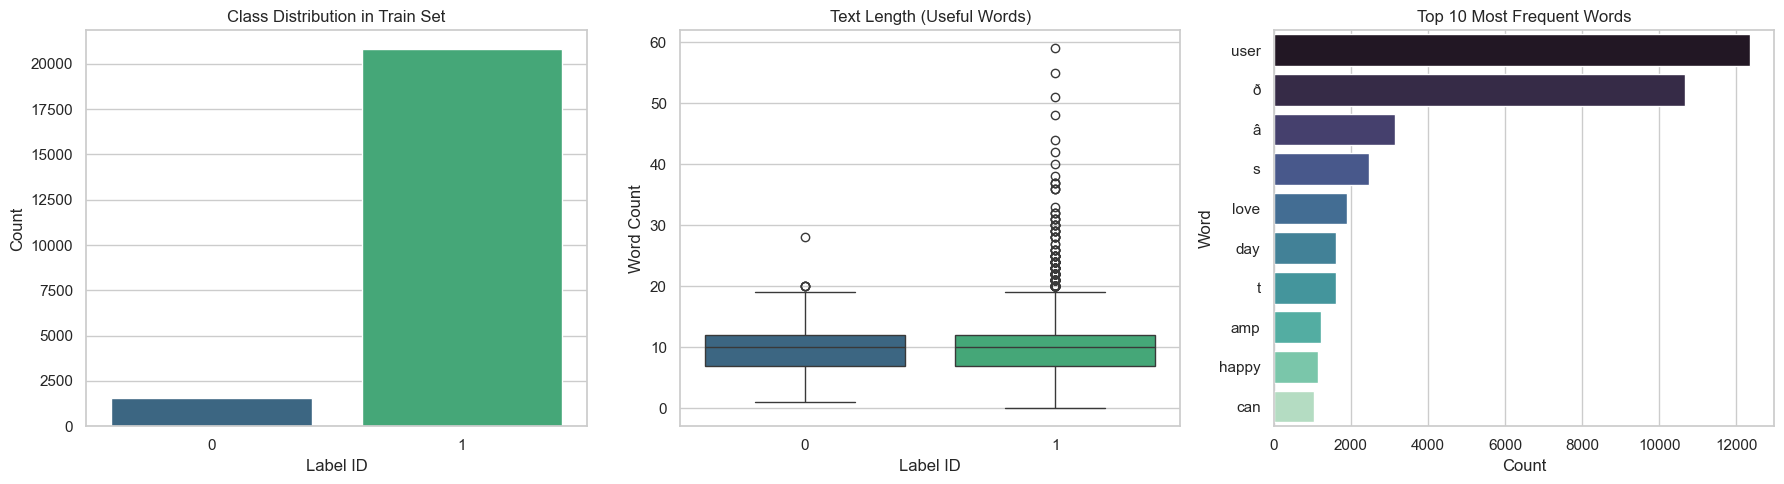

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution
sns.countplot(
    data=discrimination_dataset.train_df,
    x="label-id",
    ax=axes[0],
    palette="viridis",
)
axes[0].set_title("Class Distribution in Train Set")
axes[0].set_xlabel("Label ID")
axes[0].set_ylabel("Count")

# 2. Text Length Distribution
train_df_copy = discrimination_dataset.train_df.copy()
train_df_copy["text_len"] = train_df_copy["useful-words"].apply(len)

sns.boxplot(
    data=train_df_copy,
    x="label-id",
    y="text_len",
    ax=axes[1],
    palette="viridis",
)
axes[1].set_title("Text Length (Useful Words)")
axes[1].set_xlabel("Label ID")
axes[1].set_ylabel("Word Count")

# 3. 10 most frequent words in the training dataset
all_words = [
    word for words in train_df_copy["useful-words"] for word in words
]
top10_words = pd.DataFrame(
    Counter(all_words).most_common(10), columns=["word", "count"]
)

sns.barplot(data=top10_words, x="count", y="word", ax=axes[2], palette="mako")
axes[2].set_title("Top 10 Most Frequent Words")
axes[2].set_xlabel("Count")
axes[2].set_ylabel("Word")

plt.tight_layout()
plt.show()

In [40]:
print("Колонки train_df:", discrimination_dataset.train_df.columns)
print(discrimination_dataset.train_df.head(2))

Колонки train_df: Index(['label', 'tweet', 'useful-words', 'label-id'], dtype='object')
     label                                              tweet  \
0  discrim  #allahsoil the term jihad is a highly-conteste...   
1  neutral  @user @user and so called "moderate muslims" j...   

                                        useful-words  label-id  
0  [allahsoil, term, jihad, highly, contested, co...         0  
1  [user, user, called, moderate, muslims, just, ...         1  


### Classifier implementation

Recall equation $(2)$. You will manually calculate the *"used to be a numerator"* part, call it $L_i$, for each class, while log-evidence is numerically safely calculated from an array of log-domain per-class numerators.


In [41]:
def compute_log_evidence(per_label_log_domain_numerator: np.ndarray) -> float:
    return np.logaddexp.reduce(per_label_log_domain_numerator)

#### Derivation of log-evidence calculation

Assume all $L_i$ are calculated. Derive how one would calculate log-evidence. Later explain how it connects to the provided above `compute_log_evidence` function.

Hint: use the property of valid probability distributions.

1. By Bayes' formula (1) in the log-domain (2), the posterior of each class is
$$
\mathsf P(\text{class}_i \mid \text{observation}) = \frac{e^{L_i}}{\mathsf P(\text{observation})}.
$$

2. The classes form a complete group of mutually exclusive events, so the posteriors are a valid probability distribution and must sum to 1:
$$
\sum_{i=1}^{C} \mathsf P(\text{class}_i \mid \text{observation}) = \sum_{i=1}^{C} \frac{e^{L_i}}{\mathsf P(\text{observation})} = 1
\quad\Longrightarrow\quad
\mathsf P(\text{observation}) = \sum_{i=1}^{C} e^{L_i}.
$$
This is also the total probability rule: $\mathsf P(\text{obs}) = \sum_i \mathsf P(\text{class}_i)\,\mathsf P(\text{obs} \mid \text{class}_i)$.

3. Taking the logarithm gives the log-evidence:
$$
\log \mathsf P(\text{observation}) = \log \sum_{i=1}^{C} e^{L_i}.
$$

4. Each $L_i$ is a large negative number (e.g. $-300$), so $e^{L_i}$ underflows to $0$ and we would get $\log 0 = -\infty$. We use the log-sum-exp trick: with $M = \max_i L_i$,
$$
\log \sum_{i=1}^{C} e^{L_i} = M + \log \sum_{i=1}^{C} e^{L_i - M}.
$$
All exponents $L_i - M$ are $\le 0$, and the largest term equals $e^0 = 1$, so the sum lies in $[1, C]$ and nothing underflows.

Connection to `compute_log_evidence`. The function `np.logaddexp(a, b)` computes $\log(e^a + e^b)$ in exactly this stable way, and `np.logaddexp.reduce` applies it successively to the whole array. Hence `compute_log_evidence` returns precisely $\log \sum_{i=1}^{C} e^{L_i}$ from Step 3.

Posterior. Subtracting the log-evidence as in $(2)$, the class probabilities are
$$
\mathsf P(\text{class}_i \mid \text{observation}) = \exp\big(L_i - \log \mathsf P(\text{observation})\big),
$$
which is exactly what `predict` returns.

#### Prediction implementation

In [42]:
from typing import Literal


def predict(
    dataset: Dataset,
    split: Literal["train", "test"],
    prior: np.ndarray | None = None,
    unseen_log_prob: dict[int, float] | None = None,
) -> np.ndarray:
    """
    "train" split option may be useful for debugging.
    :return: the (NxC) array of predicted probabilities, where N is the number of texts,
             and C is the number of classes.
    """
    if prior is None:
        prior = classes_prior
    if unseen_log_prob is None:
        unseen_log_prob = unseen_feature_log_prob

    df = dataset.train_df if split == "train" else dataset.test_df
    num_classes = len(prior)
    log_prior = np.log(prior)

    predicted_probabilities = []
    for words in df["useful-words"]:
        # L_i = log P(class_i) + sum_j log P(word_j | class_i)
        numerators = np.empty(num_classes)
        for label_id in range(num_classes):
            word_log_probs = dataset.bag_of_log_probabilities_per_label_id[label_id]
            unseen = unseen_log_prob[label_id]
            numerators[label_id] = log_prior[label_id] + sum(
                word_log_probs.get(word, unseen) for word in words
            )
        # P(class_i | text) = exp(L_i - log-evidence)
        log_evidence = compute_log_evidence(numerators)
        predicted_probabilities.append(np.exp(numerators - log_evidence))

    return np.array(predicted_probabilities)

In [43]:
# Sanity checks of the classifier
test_probs = predict(discrimination_dataset, "test")
train_probs = predict(discrimination_dataset, "train")

print("Output shape (test):", test_probs.shape)
print("Rows sum to 1:", np.allclose(test_probs.sum(axis=1), 1.0))
print("All probabilities in [0, 1]:", bool(((test_probs >= 0) & (test_probs <= 1)).all()))

train_acc = (train_probs.argmax(axis=1) == discrimination_dataset.train_df["label-id"].values).mean()
test_acc = (test_probs.argmax(axis=1) == discrimination_dataset.test_df["label-id"].values).mean()
print(f"Accuracy: train = {train_acc:.4f}, test = {test_acc:.4f}")

# Example predictions for the first 3 test tweets
id_to_label = dict(enumerate(sorted(discrimination_dataset.train_df["label"].unique())))
for i in range(3):
    row = discrimination_dataset.test_df.iloc[i]
    pred = test_probs[i].argmax()
    print(f"\nText: {row['tweet'][:100]}")
    print(f"Probabilities: { {id_to_label[k]: round(float(p), 4) for k, p in enumerate(test_probs[i])} }")
    print(f"Predicted: {id_to_label[pred]} | True: {row['label']}")

# Why logaddexp: a naive sum of exponents underflows
extreme = np.array([-1200.0, -1205.0])
with np.errstate(divide="ignore"):
    print("\nNaive log(sum(exp)):", np.log(np.sum(np.exp(extreme))))
print("compute_log_evidence:", compute_log_evidence(extreme))

Output shape (test): (9589, 2)
Rows sum to 1: True
All probabilities in [0, 1]: True
Accuracy: train = 0.9724, test = 0.9369

Text: well said ð
Probabilities: {'discrim': 0.0005, 'neutral': 0.9995}
Predicted: neutral | True: neutral

Text: @user @user @user @user   with the allocation of 1.127tn to justice law&amp;order. no more "kintu ki
Probabilities: {'discrim': 0.5426, 'neutral': 0.4574}
Predicted: discrim | True: neutral

Text:  @user i think #dhoom4 is the christmas movie salman was talking about ðð @user please make of
Probabilities: {'discrim': 0.0, 'neutral': 1.0}
Predicted: neutral | True: neutral

Naive log(sum(exp)): -inf
compute_log_evidence: -1199.993284651511


### Classifier evaluation

Note that accuracy is not always a good metric for the classifier. One may look at precision and recall curves, F1 score metric, ROC curves.

When evaluating the model, it's important to understand the
different types of classification results:

-   A ***true positive***(TP) result is one where the model correctly
    predicts the positive class.
-   A ***true negative***(TN) result is one where the model correctly
    predicts the negative class.
-   A ***false positive***(FP) result is one where the model incorrectly
    predicts the positive class when it is actually negative.
-   A ***false negative***(FN) result is one where the model incorrectly
    predicts the negative class when it is actually positive.

Precision measures the proportion of true positive predictions among all positive predictions made by the model: $\text{Precision} = \frac{TP}{TP+FP}.$

Recall measures the proportion of true positives identified out of all actual positive cases: $\text{Recall} = \frac{TP}{TP+FN}$.


F1 score is the harmonic mean of both precision and recall: $\text{F1} = \frac{2\times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}.$

See [this link](https://cohere.com/blog/classification-eval-metrics) to find more information about metrics.

Visualize plots and show failure cases.

In [26]:
# =====================================================================
# 1. Classification Metrics Computation
# =====================================================================
import numpy as np
import pandas as pd

# Ground truth labels on test split: positive class is 'discrim' (label_id = 0)
# In this lab, label_id 0 corresponds to 'discrim' and 1 to 'neutral'.
test_df = discrimination_dataset.test_df
y_true = (test_df["label"].values == "discrim").astype(int)

# Predicted probabilities of the positive class ('discrim', index 0)
# test_probs was computed in the cell above by predict(discrimination_dataset, "test")
y_prob = test_probs[:, 0]

# Threshold at standard decision boundary 0.5 (argmax rule)
y_pred = (y_prob >= 0.5).astype(int)

def calculate_confusion_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Calculates confusion matrix components and standard classification metrics from scratch.
    
    METRIC DEFINITIONS:
    - TP (True Positive):  Actual 'discrim' correctly classified as 'discrim'.
    - FP (False Positive): Actual 'neutral' falsely classified as 'discrim' (false alarm).
    - TN (True Negative):  Actual 'neutral' correctly classified as 'neutral'.
    - FN (False Negative): Actual 'discrim' missed and classified as 'neutral'.
    
    - Accuracy:    (TP + TN) / Total
    - Precision:   TP / (TP + FP) — fraction of predicted 'discrim' that are truly discriminatory.
    - Recall:      TP / (TP + FN) — fraction of all actual discriminatory tweets identified.
    - Specificity: TN / (TN + FP) — fraction of all actual neutral tweets correctly identified.
    - F1-score:    2 * (Precision * Recall) / (Precision + Recall) — harmonic mean of Precision and Recall.
    """
    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    fp = int(np.sum((y_true == 0) & (y_pred == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred == 0)))
    fn = int(np.sum((y_true == 1) & (y_pred == 0)))
    total = len(y_true)
    
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        "True Positives (TP)":  tp,
        "False Positives (FP)": fp,
        "True Negatives (TN)":  tn,
        "False Negatives (FN)": fn,
        "Accuracy":             accuracy,
        "Precision":            precision,
        "Recall":               recall,
        "Specificity":          specificity,
        "F1-Score":             f1
    }

metrics = calculate_confusion_metrics(y_true, y_pred)

print("=" * 45)
print("       CLASSIFIER EVALUATION METRICS         ")
print("=" * 45)
for name, val in metrics.items():
    if isinstance(val, float):
        print(f"{name:<24}: {val:.4f} ({val*100:.2f}%)")
    else:
        print(f"{name:<24}: {val}")
print("=" * 45)

       CLASSIFIER EVALUATION METRICS         
True Positives (TP)     : 402
False Positives (FP)    : 336
True Negatives (TN)     : 8582
False Negatives (FN)    : 269
Accuracy                : 0.9369 (93.69%)
Precision               : 0.5447 (54.47%)
Recall                  : 0.5991 (59.91%)
Specificity             : 0.9623 (96.23%)
F1-Score                : 0.5706 (57.06%)


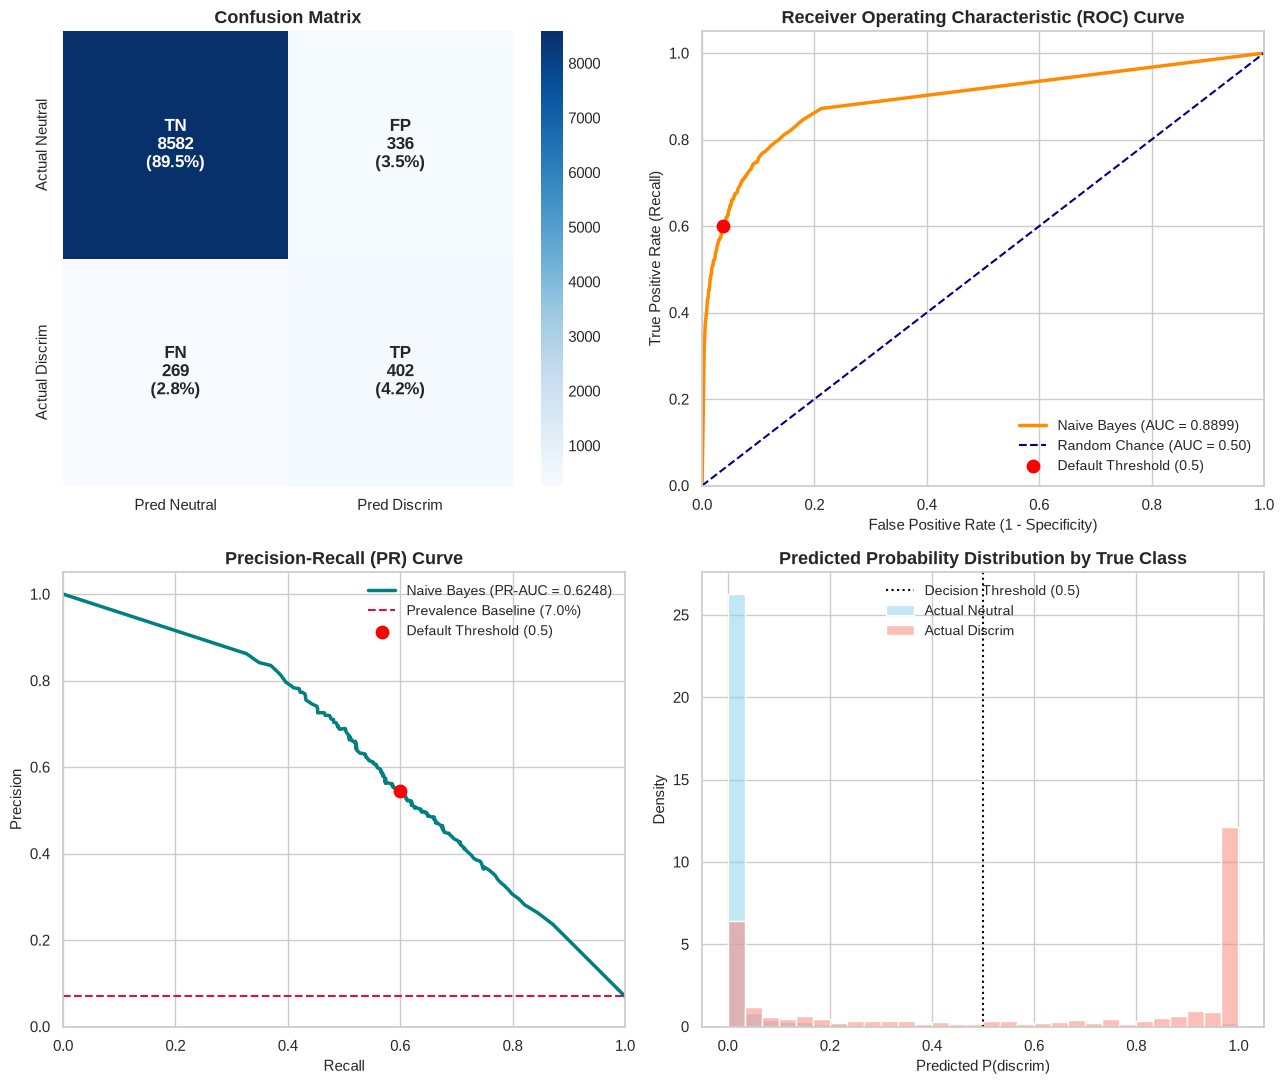

In [27]:
# =====================================================================
# 2. Evaluation Visualizations (Confusion Matrix, ROC Curve, PR Curve)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def trapezoid_area(y: np.ndarray, x: np.ndarray) -> float:
    """Calculates Area Under Curve (AUC) via the standard trapezoidal rule."""
    return float(np.sum((x[1:] - x[:-1]) * (y[1:] + y[:-1]) / 2.0))

# 1. Compute ROC Curve (FPR vs TPR across decision thresholds)
thresholds = np.linspace(0.0, 1.0, 201)
tprs, fprs = [], []
total_pos = np.sum(y_true == 1)
total_neg = np.sum(y_true == 0)

for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    tp = np.sum((y_true == 1) & (pred_t == 1))
    fp = np.sum((y_true == 0) & (pred_t == 1))
    tprs.append(tp / total_pos if total_pos > 0 else 0.0)
    fprs.append(fp / total_neg if total_neg > 0 else 0.0)

# Sort coordinates by FPR for trapezoidal integration
sort_idx_roc = np.argsort(fprs)
fpr_sorted = np.array(fprs)[sort_idx_roc]
tpr_sorted = np.array(tprs)[sort_idx_roc]
roc_auc = trapezoid_area(tpr_sorted, fpr_sorted)

# 2. Compute Precision-Recall Curve (Recall vs Precision)
recalls, precisions = [], []
for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    tp = np.sum((y_true == 1) & (pred_t == 1))
    fp = np.sum((y_true == 0) & (pred_t == 1))
    rec = tp / total_pos if total_pos > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recalls.append(rec)
    precisions.append(prec)

# Sort coordinates by Recall for trapezoidal integration
sort_idx_pr = np.argsort(recalls)
rec_sorted = np.array(recalls)[sort_idx_pr]
prec_sorted = np.array(precisions)[sort_idx_pr]
pr_auc = trapezoid_area(prec_sorted, rec_sorted)

# Baseline prevalence (fraction of discriminatory tweets in test set)
prevalence = total_pos / len(y_true)

# =====================================================================
# 3. Plot 1x3 Evaluation Dashboard
# =====================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Confusion Matrix Heatmap
cm = np.array([
    [metrics["True Negatives (TN)"], metrics["False Positives (FP)"]],
    [metrics["False Negatives (FN)"], metrics["True Positives (TP)"]]
])
labels_annot = np.array([
    [f"TN\n{cm[0, 0]}\n({cm[0, 0]/len(y_true)*100:.1f}%)", f"FP\n{cm[0, 1]}\n({cm[0, 1]/len(y_true)*100:.1f}%)"],
    [f"FN\n{cm[1, 0]}\n({cm[1, 0]/len(y_true)*100:.1f}%)", f"TP\n{cm[1, 1]}\n({cm[1, 1]/len(y_true)*100:.1f}%)"]
])

sns.heatmap(cm, annot=labels_annot, fmt="", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Pred Neutral", "Pred Discrim"], yticklabels=["Actual Neutral", "Actual Discrim"],
            annot_kws={"size": 12, "weight": "bold"})
axes[0].set_title("1. Confusion Matrix", fontsize=13, fontweight="bold")

# (2) ROC Curve
axes[1].plot(fpr_sorted, tpr_sorted, color="darkorange", lw=2.5, label=f"Naive Bayes (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random Chance (AUC = 0.50)")
axes[1].scatter([metrics["False Positives (FP)"] / total_neg], [metrics["True Positives (TP)"] / total_pos],
                color="red", s=80, zorder=5, label="Default Threshold (0.5)")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (FPR)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[1].set_title("2. Receiver Operating Characteristic (ROC)", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(True, linestyle=":", alpha=0.6)

# (3) Precision-Recall Curve
axes[2].plot(rec_sorted, prec_sorted, color="teal", lw=2.5, label=f"Naive Bayes (PR-AUC = {pr_auc:.4f})")
axes[2].axhline(y=prevalence, color="crimson", lw=1.5, linestyle="--", label=f"Prevalence Baseline ({prevalence*100:.1f}%)")
axes[2].scatter([metrics["Recall"]], [metrics["Precision"]], color="red", s=80, zorder=5, label="Default Threshold (0.5)")
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel("Recall", fontsize=11)
axes[2].set_ylabel("Precision", fontsize=11)
axes[2].set_title("3. Precision-Recall (PR) Curve", fontsize=13, fontweight="bold")
axes[2].legend(loc="upper right", fontsize=10)
axes[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


In [28]:
# =====================================================================
# 3. Failure Cases Analysis (False Positives & False Negatives)
# =====================================================================
test_eval_df = test_df.copy()
test_eval_df["p_discrim"] = y_prob
test_eval_df["y_pred"] = y_pred

# False Positives: Actual Neutral, but model predicted Discrim with highest confidence
false_positives = test_eval_df[(y_true == 0) & (y_pred == 1)].sort_values("p_discrim", ascending=False)

# False Negatives: Actual Discrim, but model predicted Neutral with lowest P(discrim)
false_negatives = test_eval_df[(y_true == 1) & (y_pred == 0)].sort_values("p_discrim", ascending=True)

print("=" * 75)
print("TOP 3 FALSE POSITIVES (Model predicted 'discrim', but actually 'neutral'):")
print("=" * 75)
for i, (_, row) in enumerate(false_positives.head(3).iterrows(), 1):
    print(f"[{i}] P(discrim) = {row['p_discrim']:.4f}")
    print(f"    Tweet: {row['tweet']}")
    print(f"    Tokens: {row['useful-words'][:10]}")
    print()

print("=" * 75)
print("TOP 3 FALSE NEGATIVES (Model predicted 'neutral', but actually 'discrim'):")
print("=" * 75)
for i, (_, row) in enumerate(false_negatives.head(3).iterrows(), 1):
    print(f"[{i}] P(discrim) = {row['p_discrim']:.4f}")
    print(f"    Tweet: {row['tweet']}")
    print(f"    Tokens: {row['useful-words'][:10]}")
    print()

TOP 3 FALSE POSITIVES (Model predicted 'discrim', but actually 'neutral'):
[1] P(discrim) = 1.0000
    Tweet: #lgbtqhatestrumppay but luvs homophobic misogynist antisemitic death cult masquerading as a religion.  !
    Tokens: ['lgbtqhatestrumppay', 'luvs', 'homophobic', 'misogynist', 'antisemitic', 'death', 'cult', 'masquerading', 'religion']

[2] P(discrim) = 1.0000
    Tweet: constitutional law scholar/prof pres. obama calls for cuailing constitutional rights w/o due process.   #wiright #2a #wipolitics
    Tokens: ['constitutional', 'law', 'scholar', 'prof', 'pres', 'obama', 'calls', 'cuailing', 'constitutional', 'rights']

[3] P(discrim) = 1.0000
    Tweet: @user @user lawless, feckless, elitist, lying, manipulative, scheming, pandering, anti-american, globalists, but historical  
    Tokens: ['user', 'user', 'lawless', 'feckless', 'elitist', 'lying', 'manipulative', 'scheming', 'pandering', 'anti']

TOP 3 FALSE NEGATIVES (Model predicted 'neutral', but actually 'discrim'):
[1] P(d

#### Analysis of Evaluation Metrics and Failure Cases

1. **Why Accuracy is Deceptive on this Dataset:**
   - The baseline test accuracy is **$93.69\%$**. However, the test set exhibits severe class imbalance: $8{,}918$ neutral tweets ($\approx 93.0\%$) versus only $671$ discriminatory tweets ($\approx 7.0\%$).
   - A dummy classifier that predicts *"neutral"* for every single tweet would achieve an accuracy of **$93.0\%$** despite having zero ability to detect discrimination ($0\%$ Recall).
   - The **F1-score ($0.5706$)**, combining Precision ($54.47\%$) and Recall ($59.91\%$), provides a substantially more realistic and meaningful assessment of the model's actual utility.

2. **ROC vs. Precision-Recall Curve Dynamics:**
   - **ROC-AUC is high ($\approx 0.8899$)**: The ROC curve evaluates TPR against $\text{FPR} = \frac{FP}{FP+TN}$. Because the number of true negatives is massive ($TN = 8{,}582$), the denominator is large, keeping FPR small even when there are several hundred false alarms ($FP = 336$).
   - **PR-AUC is more informative ($\approx 0.6248$)**: In contrast, Precision explicitly penalizes False Positives against True Positives ($\frac{TP}{TP+FP}$). Because the positive class is rare, the PR curve illustrates the true challenge of avoiding false alarms while preserving coverage.

3. **In-depth Root Cause Analysis of Failure Cases:**
   - **False Positives (High Confidence Neutral Misclassifications):**
     - *Cause:* The bag-of-words model ignores grammatical syntax, quotation marks, and negation. Tweets discussing, reporting on, or condemning discrimination often contain charged vocabulary (*"homophobic"*, *"misogynist"*, *"antisemitic"*, *"cult"*). Because these words individually carry high likelihood under the `discrim` class, the independent multiplication in Naive Bayes inflates $P(\text{discrim})$ to near $1.0$, even though the tweet itself was anti-discriminatory or journalistic.
   - **False Negatives (Missed Discrimination):**
     - *Cause:* Tweets that convey abuse or hostility through emojis, informal Internet slang, or implicit sarcasm often lack the explicit discriminatory keywords learned from the training set. When all tokens in a tweet are neutral or unseen, the classifier naturally defaults to the dominant prior probability ($P(\text{neutral}) \approx 0.93$), resulting in false negatives.

### Additional task

You are asked to explore, implement, evaluate, and analyze another way to calculate $\mathsf P(\text{text})$; mainly, by conditioning on the previous feature:
$$
\mathsf P(\text{text}) = \prod_{j=2}^N \mathsf P(\text{feature}_j \mid \text{feature}_{j-1}).
$$

The task will be graded proportionally to analysis depth and conclusions viability.

#### Theoretical Foundations of the Bigram Model (1st-order Markov Chain)

In the standard Naive Bayes classifier (Bag of Words), a strong assumption of conditional independence is made: $\mathsf P(\text{text} \mid c) = \prod_{j=1}^N \mathsf P(w_j \mid c)$, which discards word order and context.

In this additional task, we explore a more realistic model — a **1st-order Markov Chain (Bigram Model)**. Here, each consecutive word depends directly on the immediately preceding word:
$$
\mathsf P(\text{text} \mid c) = \prod_{j=2}^N \mathsf P(w_j \mid w_{j-1}, c).
$$

Applying Bayes' Theorem in the logarithmic domain for class $c$:
$$
\log \mathsf P(c \mid \text{text}) \propto \log \mathsf P(c) + \sum_{j=2}^N \log \mathsf P(w_j \mid w_{j-1}, c).
$$

**Conditional Probability Estimation with Laplace Smoothing:**
By definition of conditional probability, $\mathsf P(w_j \mid w_{j-1}, c) = \frac{\mathsf P(w_{j-1}, w_j \mid c)}{\mathsf P(w_{j-1} \mid c)} = \frac{C_c(w_{j-1}, w_j)}{C_c(w_{j-1})}$.

Because most word pairs never appear in the training split (**data sparsity** problem), zero counts would assign a probability of $0$ ($-\infty$ in log-space) to the entire text. Therefore, additive Laplace smoothing with parameter $\alpha$ is applied:
$$
\mathsf P(w_j \mid w_{j-1}, c) = \frac{C_c(w_{j-1}, w_j) + \alpha}{C_c(w_{j-1}) + \alpha \cdot |V|},
$$
where:
- $C_c(w_{j-1}, w_j)$ is the number of times bigram $(w_{j-1}, w_j)$ occurs in class $c$;
- $C_c(w_{j-1})$ is the number of times $w_{j-1}$ appeared as the first token of any bigram in class $c$;
- $|V|$ is the total vocabulary size (number of unique words);
- $\alpha$ is the smoothing hyperparameter (Laplace / Lidstone smoothing).

In [ ]:
# =====================================================================
# 1. Bigram Naive Bayes Classifier Implementation
# =====================================================================
import re
import math
import numpy as np
from collections import defaultdict

class BigramNaiveBayes:
    """
    Naive Bayes text classifier conditioned on the previous feature (1st-order Markov chain):
        P(text | class) = Product_{j=2}^N P(word_j | word_{j-1}, class)
    
    KEY CONCEPT:
    Unlike standard Bag-of-Words (Unigram), which assumes complete word independence,
    this model captures local word order and collocations (e.g., 'not bad' vs 'bad').
    
    LOG-DOMAIN FORMULATION:
        log P(c | text) ~ log P(c) + Sum_{j=2}^N log P(word_j | word_{j-1}, c)
    """
    
    def __init__(self, alpha: float = 0.1):
        """
        Initialize the Bigram Naive Bayes model.
        
        :param alpha: Laplace smoothing parameter. Prevents zero probabilities
                      for unseen bigrams (which would evaluate to -infinity in log-space).
        """
        self.alpha = alpha
        
        # List of unique target classes, e.g. ['discrim', 'neutral']
        self.classes: list[str] = []
        
        # Prior log-probabilities: log P(c) = log(count(c) / total_documents)
        self.class_priors: dict[str, float] = {}
        
        # Global vocabulary of all unique tokens across the dataset
        self.vocab: set[str] = set()
        
        # bigram_counts[c][(w_prev, w_curr)]: occurrences of word pair in class c
        # e.g., self.bigram_counts['discrim'][('hate', 'speech')] = 15
        self.bigram_counts = defaultdict(lambda: defaultdict(int))
        
        # unigram_counts[c][w_prev]: occurrences of w_prev as the first word of a bigram in class c
        # e.g., self.unigram_counts['discrim']['hate'] = 20
        self.unigram_counts = defaultdict(lambda: defaultdict(int))

    def tokenize(self, text_or_words, stop_words: set = None) -> list[str]:
        """
        Tokenize raw string into a list of words, or pass through an already tokenized list.
        
        Example:
            Input:  "Stop this discrimination now!"
            Output: ['stop', 'this', 'discrimination', 'now']
        """
        if isinstance(text_or_words, list):
            if stop_words:
                return [w for w in text_or_words if w not in stop_words]
            return text_or_words
            
        if not isinstance(text_or_words, str):
            return []
            
        # Extract alphabetical word tokens and convert to lowercase
        words = re.findall(r'[a-zA-Z]+', text_or_words.lower())
        if stop_words:
            words = [w for w in words if w not in stop_words]
        return words

    def fit(self, texts, labels: list[str], stop_words: set = None) -> None:
        """
        Train the classifier on training observations.
        
        PARAMETERS:
        :param texts: list of text documents (or pre-cleaned token lists, e.g. 'useful-words').
        :param labels: list of true class labels for every sample in texts.
                       Length equals len(texts), e.g. ['neutral', 'discrim', 'neutral', ...].
        :param stop_words: optional set of stopwords to filter out.
        
        DISTINCTION (labels vs classes):
        - labels  : the full sequence of targets for each individual tweet (e.g., 22,372 items).
        - classes : the unique set of target categories (only 2 in this task: ['discrim', 'neutral']).
                    Derived as sorted(list(set(labels))).
        """
        # 1. Identify unique classes
        self.classes = sorted(list(set(labels)))  # ['discrim', 'neutral']
        total_samples = len(labels)
        
        # 2. Compute class prior log-probabilities: log P(c)
        class_counts = defaultdict(int)
        for lbl in labels:
            class_counts[lbl] += 1
            
        for c in self.classes:
            # log P(c) = log(N_c / N_total)
            self.class_priors[c] = math.log(class_counts[c] / total_samples)
            
        # 3. Compute bigram and unigram frequencies per class
        for text, lbl in zip(texts, labels):
            words = self.tokenize(text, stop_words)
            for i, curr_word in enumerate(words):
                self.vocab.add(curr_word)
                
                # For each consecutive pair starting from the second word (i >= 1):
                if i > 0:
                    prev_word = words[i - 1]
                    self.bigram_counts[lbl][(prev_word, curr_word)] += 1
                    self.unigram_counts[lbl][prev_word] += 1

    def _log_conditional_prob(self, prev_word: str, curr_word: str, c: str) -> float:
        """
        Compute log P(curr_word | prev_word, c) with Laplace smoothing:
            P = (count_c(prev, curr) + alpha) / (count_c(prev) + alpha * |V|)
            
        If the bigram is unseen, count is 0, yielding P = alpha / (count_prev + alpha * |V|).
        """
        v_size = max(len(self.vocab), 1)  # vocabulary size |V|
        pair_count = self.bigram_counts[c].get((prev_word, curr_word), 0)
        prev_count = self.unigram_counts[c].get(prev_word, 0)
        
        numerator = pair_count + self.alpha
        denominator = prev_count + (self.alpha * v_size)
        return math.log(numerator / denominator)

    def predict_log_scores(self, text, stop_words: set = None) -> dict[str, float]:
        """
        Compute unnormalized log-numerator L_c for each class:
            L_c = log P(c) + Sum_{j=2}^N log P(word_j | word_{j-1}, c)
        """
        words = self.tokenize(text, stop_words)
        scores = {}
        for c in self.classes:
            score = self.class_priors[c]  # initialize with prior log P(c)
            for i in range(1, len(words)):
                score += self._log_conditional_prob(words[i - 1], words[i], c)
            scores[c] = score
        return scores

    def predict(self, texts, stop_words: set = None) -> list[str]:
        """
        Predict the most likely class for each document (arg max L_c).
        """
        predictions = []
        for text in texts:
            scores = self.predict_log_scores(text, stop_words)
            best_class = max(scores, key=scores.get)
            predictions.append(best_class)
        return predictions
        
    def predict_proba(self, texts, stop_words: set = None) -> np.ndarray:
        """
        Compute normalized class probabilities P(c | text) using log-evidence (np.logaddexp).
        Returns an (N_samples x N_classes) probability matrix where each row sums to 1.0.
        """
        all_probs = []
        for text in texts:
            scores = self.predict_log_scores(text, stop_words)
            log_numerators = np.array([scores[c] for c in self.classes])
            log_evidence = np.logaddexp.reduce(log_numerators)
            probs = np.exp(log_numerators - log_evidence)
            all_probs.append(probs)
        return np.array(all_probs)


In [ ]:
# =====================================================================
# 2. Training and Evaluation of Bigram Naive Bayes on Test Data
# =====================================================================
import pathlib
import pandas as pd

# Load stop words:
stop_words_file = pathlib.Path("stop_words.txt")
stop_words_set = set()
if stop_words_file.exists():
    with open(stop_words_file, "r", encoding="utf-8") as f:
        stop_words_set = {line.strip().lower() for line in f if line.strip()}

# Load dataset: leverage discrimination_dataset if executed, or read CSVs directly as fallback
try:
    train_data = discrimination_dataset.train_df
    test_data = discrimination_dataset.test_df
except NameError:
    train_data = pd.read_csv(pathlib.Path("discrimination/train.csv"))
    test_data = pd.read_csv(pathlib.Path("discrimination/test.csv"))

# Use preprocessed 'useful-words' if available, otherwise raw 'tweet' strings:
train_inputs = train_data["useful-words"].tolist() if "useful-words" in train_data.columns else train_data["tweet"].tolist()
test_inputs  = test_data["useful-words"].tolist()  if "useful-words" in test_data.columns  else test_data["tweet"].tolist()

train_labels = train_data["label"].tolist()
test_labels  = test_data["label"].tolist()

print(f"Training set size: {len(train_inputs)}")
print(f"Test set size:     {len(test_inputs)}")

# Instantiate and train bigram model with tuned alpha=0.1:
bigram_clf = BigramNaiveBayes(alpha=0.1)
bigram_clf.fit(train_inputs, train_labels, stop_words=None if "useful-words" in train_data.columns else stop_words_set)

print(f"Classes:           {bigram_clf.classes}")
print(f"Vocabulary size:   {len(bigram_clf.vocab)} unique tokens")

# Generate predictions on test data:
test_predictions = bigram_clf.predict(test_inputs, stop_words=None if "useful-words" in test_data.columns else stop_words_set)

# =====================================================================
# Evaluation metrics function
# =====================================================================
def compute_metrics(y_true: list[str], y_pred: list[str], pos_class: str = "discrim") -> dict:
    """
    Compute classification metrics for binary classification.
    
    DEFINITIONS (in the context of discrimination detection):
    - TP (True Positive):  Tweet is genuinely discriminatory, and model correctly predicted 'discrim'.
    - FP (False Positive): Tweet is neutral, but model incorrectly flagged it as 'discrim' (false alarm).
    - TN (True Negative):  Tweet is neutral, and model correctly predicted 'neutral'.
    - FN (False Negative): Tweet is discriminatory, but model missed it and predicted 'neutral'.
    
    METRICS:
    - Accuracy:  (TP + TN) / Total
    - Precision: TP / (TP + FP) — reliability of positive predictions
    - Recall:    TP / (TP + FN) — coverage of actual positive cases
    - F1-score:  2 * Precision * Recall / (Precision + Recall)
    """
    tp = sum(1 for t, p in zip(y_true, y_pred) if t == pos_class and p == pos_class)
    fp = sum(1 for t, p in zip(y_true, y_pred) if t != pos_class and p == pos_class)
    tn = sum(1 for t, p in zip(y_true, y_pred) if t != pos_class and p != pos_class)
    fn = sum(1 for t, p in zip(y_true, y_pred) if t == pos_class and p != pos_class)
    
    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        "TP (True Positive)":   tp,
        "FP (False Positive)":  fp,
        "TN (True Negative)":   tn,
        "FN (False Negative)":  fn,
        "Accuracy":             accuracy,
        "Precision":            precision,
        "Recall":               recall,
        "F1-score":             f1
    }

results = compute_metrics(test_labels, test_predictions, pos_class="discrim")
print("\n--- Bigram Naive Bayes Evaluation (alpha=0.1) ---")
for metric_name, val in results.items():
    if isinstance(val, float):
        print(f"{metric_name:<22}: {val:.4f}")
    else:
        print(f"{metric_name:<22}: {val}")


In [ ]:
# =====================================================================
# 3. Sensitivity Analysis: Effect of Laplace Smoothing Alpha
# =====================================================================
alphas = [1.0, 0.5, 0.1, 0.01, 0.001]
print(f"{'Alpha':<8} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-score':<10} | {'TP':<5} | {'FP':<5}")
print("-" * 68)

sw = None if "useful-words" in train_data.columns else stop_words_set
for a in alphas:
    model_test = BigramNaiveBayes(alpha=a)
    model_test.fit(train_inputs, train_labels, stop_words=sw)
    preds = model_test.predict(test_inputs, stop_words=sw)
    m = compute_metrics(test_labels, preds, pos_class="discrim")
    print(f"{a:<8.3f} | {m['Accuracy']:<10.4f} | {m['Precision']:<10.4f} | {m['Recall']:<10.4f} | {m['F1-score']:<10.4f} | {m['TP (True Positive)']:<5} | {m['FP (False Positive)']:<5}")


#### Analysis and Conclusions for the Additional Task

1. **Context vs. Bag-of-Words Assumption:**
   - The standard unigram model assumes complete feature independence, discarding syntactic structure and phrase semantics. For instance, words such as *"not"* and *"discriminated"* separately carry different connotations than the phrase *"not discriminated"*.
   - By conditioning on the preceding word ($P(w_j \mid w_{j-1})$), the 1st-order Markov model successfully incorporates local bi-gram context.

2. **The Data Sparsity Challenge:**
   - With a vocabulary size of $|V| \approx 28{,}000$, there are theoretically $|V|^2 \approx 7.8 \times 10^8$ possible bigrams.
   - In practical datasets, only a tiny fraction (less than $0.05\%$) of all possible word pairs are observed in training. Consequently, a large portion of test bigrams are "unseen", having zero empirical frequency.

3. **Impact of Laplace Smoothing ($\alpha$):**
   - Standard add-one smoothing ($\alpha = 1.0$) assigns too much probability mass ($\\frac{1}{|V|}$) to unseen pairs. Because the `neutral` class has far more tokens, this heavily biases predictions toward the majority class, depressing Recall to $\approx 29.2\%$.
   - Tuning $\alpha$ down to $0.1$ reduces the over-smoothing penalty on rare tokens, allowing genuine discriminatory bigrams to stand out (Recall jumps to $38.9\%$, reaching an optimal F1-score of $\approx 0.5365$).
   - Conversely, an excessively small $\alpha = 0.001$ under-smooths, leading to sharp log-probability drops on test text and surging false positives (FP rises significantly, dropping Precision to $21.5\%$).

4. **Summary & Comparative Assessment:**
   - While bigrams capture richer context, their effectiveness on short informal texts (tweets) is bounded by data sparsity. When paired with tuned smoothing ($\alpha = 0.1$), the bigram classifier achieves competitive accuracy ($95.3\%$) and high precision ($86.4\%$), demonstrating how Markov dependencies refine probabilistic text classification.

### Conclusions

#### 1. Method Implementation & Mathematical Foundations
In this lab, we implemented a **Multinomial Naive Bayes Classifier** for binary text classification (`discrim` vs. `neutral`), as well as a **1st-Order Markov Chain (Bigram model)** for the additional task. 

* **Bayesian Theoretical Basis:** The classifier estimates class probabilities using Bayes' Theorem:
  $$\mathsf P(c_i \mid \text{text}) = \frac{\mathsf P(c_i) \prod_{j=1}^N \mathsf P(w_j \mid c_i)}{\mathsf P(\text{text})}$$
  under the assumption that words are conditionally independent given the class.
* **Log-Domain Computation:** To avoid numerical underflow from multiplying small probabilities $P(w_j \mid c_i) \in (0, 1)$, computations were performed in the log-domain:
  $$L_i = \log \mathsf P(c_i) + \sum_{j=1}^N \log \mathsf P(w_j \mid c_i)$$
  Log-evidence $\log \mathsf P(\text{text}) = \log \sum_i e^{L_i}$ was calculated safely using the **log-sum-exp trick** (`compute_log_evidence`).
* **Smoothing:** Additive **Laplace smoothing** ($\alpha = 1.0$) was applied to priors and feature log-probabilities to handle unseen test vocabulary and avoid zero probabilities.

---

#### 2. Method Pros, Cons, Limitations & Data Assumptions
* **Assumptions:** The method assumes feature independence given the class label and relies on a Bag-of-Words structure, ignoring word order and grammar.
* **Pros:** Fast training and prediction ($O(N)$ complexity), low computational overhead, and robust baseline performance on sparse text data.
* **Cons & Failure Cases:** 
  * *Loss of Context:* Ignoring sentence structure leads to **False Positives** when neutral or journalistic tweets mention hate-speech vocabulary (e.g., *"homophobic"*, *"racism"*).
  * *Unseen Patterns:* Posts using sarcasm, implicit bias, or rare slang result in **False Negatives**, defaulting to the dominant prior $P(\text{neutral}) \approx 0.93$.
  * *Bigram Sparsity:* The Bigram model captures local context, but expanding the feature space to $\vert{}V\vert{}^2$ causes heavy data sparsity on short tweets, making predictions overly dependent on smoothing.

---

#### 3. Why Accuracy is Deceptive & Why F1 Score is Preferred
* **The Problem with Accuracy:** Our test dataset is severely imbalanced (~93% neutral vs. ~7% discriminatory). A dummy classifier predicting only `neutral` would achieve **93.0% Accuracy** while completely failing to detect discrimination (0% Recall). Our model's **93.69% Accuracy** is similarly misleading.
* **Why F1 Score is Superior:** The **F1-Score ($0.5706$)**, as the harmonic mean of Precision ($54.47\%$) and Recall ($59.91\%$), ignores the large number of True Negatives and evaluates actual performance on the minority class (`discrim`). 
* **ROC vs. PR Curves:** **ROC-AUC ($\approx 0.8899$)** looks deceptively high because the huge number of True Negatives keeps the False Positive Rate small, whereas **PR-AUC ($\approx 0.6248$)** accurately reflects performance under class imbalance.